In [2]:
import pandas as pd
df = pd.read_excel("../data/RDSon_vs_Tj.xlsx")

In [6]:
df.head()


,Tj (°C),RDS(on) (mΩ),Condition,Source
0,25,1.49,"VGS=10V, ID=100A",Datasheet Fig. 8
1,50,1.69,"VGS=10V, ID=100A",Datasheet Fig. 8
2,75,1.91,"VGS=10V, ID=100A",Datasheet Fig. 8
3,100,2.17,"VGS=10V, ID=100A",Datasheet Fig. 8
4,125,2.44,"VGS=10V, ID=100A",Datasheet Fig. 8


In [5]:
df.columns

Index(['Tj (°C)', 'RDS(on) (mΩ)', 'Condition', 'Source'], dtype='object')

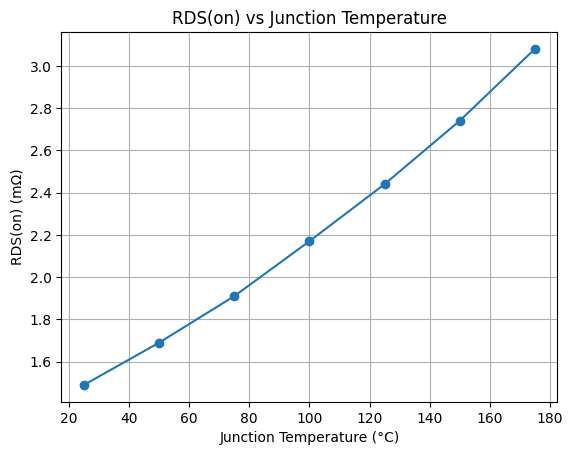

In [7]:
import matplotlib.pyplot as plt
plt.plot(df["Tj (°C)"], df["RDS(on) (mΩ)"], marker="o")
plt.xlabel("Junction Temperature (°C)")
plt.ylabel("RDS(on) (mΩ)")
plt.title("RDS(on) vs Junction Temperature")
plt.grid()

plt.show()

In [8]:
I = 100
df['Power_loss(W)']= I**2*df["RDS(on) (mΩ)"] / 1000

In [9]:
df.head()

,Tj (°C),RDS(on) (mΩ),Condition,Source,Power_loss(W)
0,25,1.49,"VGS=10V, ID=100A",Datasheet Fig. 8,14.9
1,50,1.69,"VGS=10V, ID=100A",Datasheet Fig. 8,16.9
2,75,1.91,"VGS=10V, ID=100A",Datasheet Fig. 8,19.1
3,100,2.17,"VGS=10V, ID=100A",Datasheet Fig. 8,21.7
4,125,2.44,"VGS=10V, ID=100A",Datasheet Fig. 8,24.4


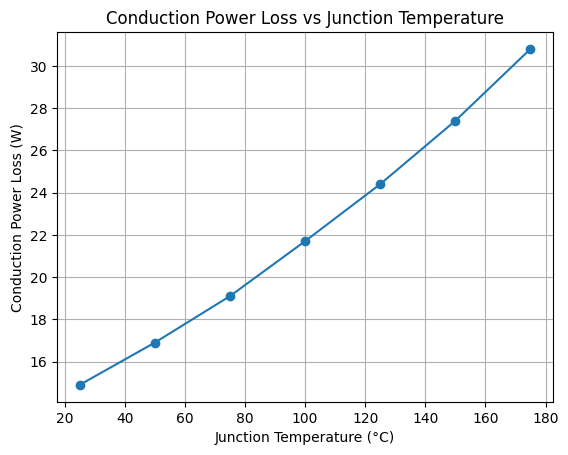

In [10]:
plt.plot(df["Tj (°C)"], df["Power_loss(W)"], marker="o")

plt.xlabel("Junction Temperature (°C)")
plt.ylabel("Conduction Power Loss (W)")
plt.title("Conduction Power Loss vs Junction Temperature")
plt.grid()

plt.show()

In [11]:
increase = (df["Power_loss(W)"].iloc[-1] - df["Power_loss(W)"].iloc[0]) / df["Power_loss(W)"].iloc[0] * 100

print(f"Power loss increase: {increase:.1f}%")

Power loss increase: 106.7%


## Observation

- Junction Temperature가 증가할수록 RDS(on)이 증가하였다.
- 동일한 Drain Current 100 A 조건에서 RDS(on)의 증가로 인해 전도손실도 증가하였다.
- 25°C에서 약 14.9 W였던 전도손실은 175°C에서 약 30.8 W까지 증가하였다.

## Interpretation

MOSFET의 온도가 상승하면 RDS(on)이 증가하고, 동일한 전류에서도 I²R 손실이 커진다.
따라서 온도 변화와 전력손실은 서로 독립적이지 않으며, 이후 Junction Temperature를 계산할 때 온도 의존 RDS(on)을 고려할 필요가 있다.